# FINANCE 361 — Topic 15: Bonds

**Instructor:** Dr. Zicheng (Leo) Xiao  
**Institution:** University of Auckland — FINANCE 361: Modern Investment Theory  
**Week:** 9

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Price a coupon bond by discounting each cash flow individually.
2. Apply the annuity shortcut formula for bonds with many coupon periods.
3. Solve for the yield to maturity (YTM) of a bond given its market price.
4. Compute accrued interest and the dirty price for a bond traded between coupon dates.
5. Bootstrap a simple zero-coupon yield curve from observed coupon bond prices.
6. Analyse the price sensitivity of bonds to changes in discount rates (price-yield relationship).

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import brentq

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'

# ── Named constants (the example bond used throughout the lecture) ──────────
FACE      = 100.0   # Face value F ($)
COUP_RATE = 0.08    # Annual coupon rate c
MATURITY  = 2.0     # Maturity T (years)
FREQ      = 4       # Payments per year (quarterly)
DELTA     = 1 / FREQ  # Coupon period length Δ

---
## Section 1 — Bond Cash Flows

The coupon paid at each payment date is:

$$C = c \times F \times \Delta$$

### Predict-Then-Verify 1
> **Before running the cell below**, predict: for the Spark bond (F=$100, c=8%, T=2yr, quarterly), what is the coupon per period? How many payment dates are there? What is the final total cash flow?

In [2]:
def bond_cashflows(F: float, c: float, T: float, freq: int) -> pd.DataFrame:
    """Return a DataFrame of all bond cash flows."""
    delta = 1 / freq
    C = c * F * delta
    n = round(T / delta)
    times = [round(k * delta, 6) for k in range(1, n + 1)]
    coupons = [C] * n
    principal = [0.0] * n
    principal[-1] = F
    total = [c_ + p for c_, p in zip(coupons, principal)]
    return pd.DataFrame({'t (years)': times,
                         'Coupon C ($)': coupons,
                         'Principal ($)': principal,
                         'Total CF ($)': total})

cf = bond_cashflows(FACE, COUP_RATE, MATURITY, FREQ)
print(f"Coupon per period: ${COUP_RATE * FACE * DELTA:.2f}")
print()
print(cf.to_string(index=False))

Coupon per period: $2.00

 t (years)  Coupon C ($)  Principal ($)  Total CF ($)
      0.25           2.0            0.0           2.0
      0.50           2.0            0.0           2.0
      0.75           2.0            0.0           2.0
      1.00           2.0            0.0           2.0
      1.25           2.0            0.0           2.0
      1.50           2.0            0.0           2.0
      1.75           2.0            0.0           2.0
      2.00           2.0          100.0         102.0


---
## Section 2 — Bond Pricing

$$B_0 = \frac{F}{(1+r)^T} + \sum_{t \in K} \frac{C}{(1+r)^t}$$

### Predict-Then-Verify 2
> The Spark bond has a coupon rate of 8% and we discount at r = 5%. Before running: will the price be **above**, **below**, or **exactly** $100? Write your prediction.

In [3]:
def bond_price(F: float, c: float, T: float, freq: int, r: float) -> float:
    """Price a coupon bond by discounting all cash flows."""
    delta = 1 / freq
    C = c * F * delta
    n = round(T / delta)
    times = np.array([k * delta for k in range(1, n + 1)])
    discount_factors = 1 / (1 + r) ** times
    pv_coupons    = (C * discount_factors).sum()
    pv_principal  = F / (1 + r) ** T
    return pv_coupons + pv_principal


def bond_price_annuity(F: float, c: float, T: float, freq: int, r: float) -> float:
    """Price a coupon bond using the annuity shortcut formula."""
    delta = 1 / freq
    C = c * F * delta
    s = (1 + r) ** delta - 1          # Periodic discount rate
    n = T / delta                       # Number of coupon periods
    pv_coupons   = (C / s) * (1 - 1 / (1 + s) ** n)
    pv_principal = F / (1 + r) ** T
    return pv_coupons + pv_principal


r = 0.05
p_direct  = bond_price(FACE, COUP_RATE, MATURITY, FREQ, r)
p_annuity = bond_price_annuity(FACE, COUP_RATE, MATURITY, FREQ, r)

print(f"r = {r:.1%}")
print(f"Price (direct sum):     ${p_direct:.4f}")
print(f"Price (annuity formula):{p_annuity:.4f}")
print(f"Difference:             ${abs(p_direct - p_annuity):.2e}  ← should be ~0")

r = 5.0%
Price (direct sum):     $105.8543
Price (annuity formula):105.8543
Difference:             $0.00e+00  ← should be ~0


In [4]:
# Detailed pricing table with discount factors
cf_table = bond_cashflows(FACE, COUP_RATE, MATURITY, FREQ).copy()
times = cf_table['t (years)'].values
cf_table['d_t'] = (1 / (1 + r) ** times).round(4)
cf_table['PV(CF)'] = (cf_table['Total CF ($)'] * cf_table['d_t']).round(4)
print(cf_table.to_string(index=False))
print(f"\nTotal B0 = ${cf_table['PV(CF)'].sum():.4f}")

 t (years)  Coupon C ($)  Principal ($)  Total CF ($)    d_t  PV(CF)
      0.25           2.0            0.0           2.0 0.9879  1.9758
      0.50           2.0            0.0           2.0 0.9759  1.9518
      0.75           2.0            0.0           2.0 0.9641  1.9282
      1.00           2.0            0.0           2.0 0.9524  1.9048
      1.25           2.0            0.0           2.0 0.9408  1.8816
      1.50           2.0            0.0           2.0 0.9294  1.8588
      1.75           2.0            0.0           2.0 0.9182  1.8364
      2.00           2.0          100.0         102.0 0.9070 92.5140

Total B0 = $105.8514


---
## Section 3 — Price–Yield Relationship

Bond price and yield move in **opposite directions**.

### Predict-Then-Verify 3
> Before plotting: at what discount rate do you expect the bond to price at exactly par ($100)? Why? Write your prediction.

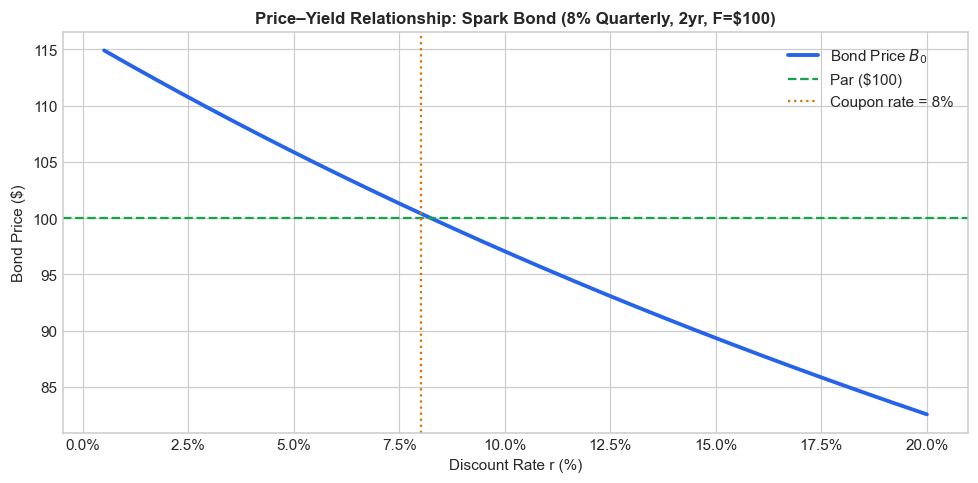

Price at r = coupon rate (8%): $100.4211


In [5]:
rates  = np.linspace(0.005, 0.20, 300)
prices = [bond_price(FACE, COUP_RATE, MATURITY, FREQ, r_) for r_ in rates]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rates * 100, prices, color='#2563eb', linewidth=2.5, label='Bond Price $B_0$')
ax.axhline(FACE, color='#16a34a', linewidth=1.5, linestyle='--', label='Par ($100)')
ax.axvline(COUP_RATE * 100, color='#d97706', linewidth=1.5, linestyle=':', label=f'Coupon rate = {COUP_RATE:.0%}')

ax.set_xlabel('Discount Rate r (%)')
ax.set_ylabel('Bond Price ($)')
ax.set_title('Price–Yield Relationship: Spark Bond (8% Quarterly, 2yr, F=$100)',
             fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

print(f"Price at r = coupon rate ({COUP_RATE:.0%}): ${bond_price(FACE, COUP_RATE, MATURITY, FREQ, COUP_RATE):.4f}")

---
## Section 4 — Yield to Maturity (YTM)

YTM is the discount rate $y$ that sets the present value of all cash flows equal to the market price $M_0$. There is no closed-form solution — we solve numerically.

### Predict-Then-Verify 4
> The market price of the Spark bond is $102. The coupon rate is 8%. Before running: will the YTM be **above 8%**, **below 8%**, or **exactly 8%**? Why?

In [6]:
def ytm(F: float, c: float, T: float, freq: int, market_price: float) -> float:
    """Solve for YTM using Brent's method."""
    def objective(r):
        return bond_price(F, c, T, freq, r) - market_price
    return brentq(objective, 1e-6, 10.0)


prices_to_check = [105.8543, 102.00, 100.00, 95.00]

print(f"{'Market Price':>14}  {'YTM (annual)':>14}  {'Quarterly IRR':>14}  {'Premium/Discount':>18}")
print('-' * 68)
for mp in prices_to_check:
    y = ytm(FACE, COUP_RATE, MATURITY, FREQ, mp)
    q_irr = (1 + y) ** (1 / FREQ) - 1
    status = 'Premium' if mp > FACE else ('Discount' if mp < FACE else 'Par')
    print(f"${mp:>13.4f}  {y:>13.4%}  {q_irr:>13.4%}  {status:>18}")

  Market Price    YTM (annual)   Quarterly IRR    Premium/Discount
--------------------------------------------------------------------
$     105.8543        5.0000%        1.2272%             Premium
$     102.0000        7.1023%        1.7301%             Premium
$     100.0000        8.2432%        2.0000%                 Par
$      95.0000       11.2600%        2.7034%            Discount


---
## Section 5 — Accrued Interest and Dirty Price

$$\text{AI} = C \times \frac{\text{days since last coupon}}{\text{days in coupon period}}$$
$$\text{Dirty Price} = \text{Clean Price} + \text{Accrued Interest}$$

### Predict-Then-Verify 5
> An annual coupon bond (F=$100, c=10%) pays coupons on 15 December. You sell it on 1 December at a clean price of $96. Before running: what do you expect the invoice (dirty) price to be?

In [7]:
def accrued_interest(F: float, c: float, freq: int,
                     days_since_last_coupon: int,
                     days_in_period: int = 365) -> float:
    """Compute accrued interest (ACT/ACT convention)."""
    C_annual = c * F / freq
    return C_annual * (days_since_last_coupon / days_in_period)


clean_price = 96.0
AI = accrued_interest(F=100, c=0.10, freq=1,
                      days_since_last_coupon=350,
                      days_in_period=365)
dirty_price = clean_price + AI

print(f"Annual coupon (c=10%, F=$100): $10.00")
print(f"Days since last coupon:          350")
print(f"Accrued Interest:              ${AI:.2f}")
print(f"Clean price:                   ${clean_price:.2f}")
print(f"Dirty (invoice) price:         ${dirty_price:.2f}")

Annual coupon (c=10%, F=$100): $10.00
Days since last coupon:          350
Accrued Interest:              $9.59
Clean price:                   $96.00
Dirty (invoice) price:         $105.59


---
## Section 6 — Zero Coupon Bonds and Bootstrapping

A zero coupon bond (zero) pays only the face value at maturity:
$$Z_{0,T} = \frac{F_T}{(1 + r_{0,T})^T}$$

The **zero rate** $r_{0,T}$ can be **bootstrapped** from observed coupon bond prices.

### Predict-Then-Verify 6
> Given: a 1-year zero priced at $96.15 (F=$100) and a 2-year annual coupon bond (c=8%, F=$100) priced at $103.20. Before running: can you sketch how you would extract the 2-year zero rate from these two instruments?

In [8]:
# ── Bootstrap a 2-point zero curve ──────────────────────────────────────────
# Observed market prices
P_1yr_zero  = 96.15     # 1-year zero coupon bond, F=100
P_2yr_coupon = 103.20   # 2-year annual coupon bond, c=8%, F=100
F_boot = 100.0

# Step 1: extract 1-year zero rate from the 1-year zero
z1 = (F_boot / P_1yr_zero) - 1
d1 = 1 / (1 + z1)   # 1-year discount factor

# Step 2: extract 2-year zero rate from the 2-year coupon bond
# P = 8*d1 + 108*d2  =>  d2 = (P - 8*d1) / 108
coupon_2yr = 0.08 * F_boot
d2 = (P_2yr_coupon - coupon_2yr * d1) / (F_boot + coupon_2yr)
z2 = (1 / d2) ** 0.5 - 1

print("=== Bootstrapped Zero Rates ===")
print(f"1-year zero rate z(0,1): {z1:.4%}")
print(f"2-year zero rate z(0,2): {z2:.4%}")
print(f"\n1-year discount factor d(0,1): {d1:.6f}")
print(f"2-year discount factor d(0,2): {d2:.6f}")

# Verify: reprice the 2-year coupon bond with bootstrapped discount factors
repriced = coupon_2yr * d1 + (F_boot + coupon_2yr) * d2
print(f"\nReprice 2yr coupon bond: ${repriced:.4f}  (should be ${P_2yr_coupon:.2f})",
      "✓" if abs(repriced - P_2yr_coupon) < 0.01 else "✗")

=== Bootstrapped Zero Rates ===
1-year zero rate z(0,1): 4.0042%
2-year zero rate z(0,2): 6.3389%

1-year discount factor d(0,1): 0.961500
2-year discount factor d(0,2): 0.884333

Reprice 2yr coupon bond: $103.2000  (should be $103.20) ✓


---
## Section 7 — Challenge: Price Sensitivity Across Bond Types

Compare how a **short-term bond**, a **long-term bond**, and a **zero coupon bond** respond to a 1% shift in the discount rate.

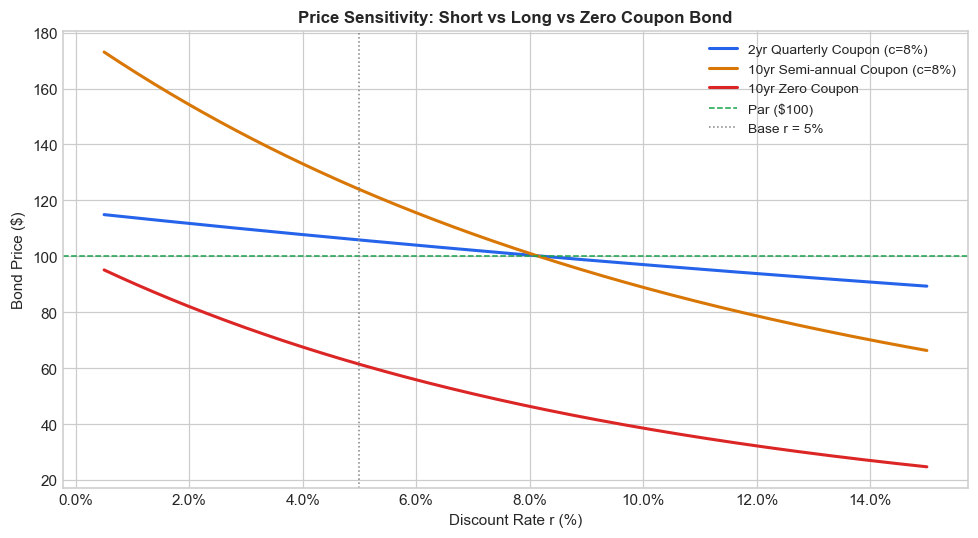


Bond                                      Price @ 5%  Price @ 6%    % change
----------------------------------------------------------------------------
2yr Quarterly Coupon (c=8%)               $ 105.8543  $ 103.9928      -1.76%
10yr Semi-annual Coupon (c=8%)            $ 123.9280  $ 115.5905      -6.73%
10yr Zero Coupon                          $  61.3913  $  55.8395      -9.04%


In [9]:
BONDS = [
    {'label': '2yr Quarterly Coupon (c=8%)',  'c': 0.08, 'T': 2,  'freq': 4},
    {'label': '10yr Semi-annual Coupon (c=8%)', 'c': 0.08, 'T': 10, 'freq': 2},
    {'label': '10yr Zero Coupon',              'c': 0.00, 'T': 10, 'freq': 1},
]

r_base = 0.05
r_vals = np.linspace(0.005, 0.15, 300)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2563eb', '#d97706', '#dc2626']

for bond, col in zip(BONDS, colors):
    prices = [bond_price(FACE, bond['c'], bond['T'], bond['freq'], r_)
              for r_ in r_vals]
    ax.plot(r_vals * 100, prices, color=col, linewidth=2, label=bond['label'])

ax.axhline(FACE, color='#16a34a', linewidth=1, linestyle='--', label='Par ($100)')
ax.axvline(r_base * 100, color='grey', linewidth=1, linestyle=':', label=f'Base r = {r_base:.0%}')

ax.set_xlabel('Discount Rate r (%)')
ax.set_ylabel('Bond Price ($)')
ax.set_title('Price Sensitivity: Short vs Long vs Zero Coupon Bond', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Quantify: how much does price change per 1% increase in r?
print(f"\n{'Bond':40s}  {'Price @ 5%':>10}  {'Price @ 6%':>10}  {'% change':>10}")
print('-' * 76)
for bond in BONDS:
    p5 = bond_price(FACE, bond['c'], bond['T'], bond['freq'], 0.05)
    p6 = bond_price(FACE, bond['c'], bond['T'], bond['freq'], 0.06)
    pct_chg = (p6 - p5) / p5 * 100
    print(f"{bond['label']:40s}  ${p5:>9.4f}  ${p6:>9.4f}  {pct_chg:>9.2f}%")

---
## Section 8 — Reflect: Explain to Teach

Answer the following questions **in your own words** (without using AI). Aim for 2–3 sentences each.

1. **Why does a bond price at a premium when its coupon rate exceeds the discount rate?** Explain using the concept of present value — don't just say "investors prefer higher coupons."

2. **Why can't you directly compare the YTMs of two bonds with different maturities as measures of their relative return?**

3. **What is the economic intuition for accrued interest?** Who benefits from the accrued interest convention, and why would markets break down without it?

4. **The price–yield plots above show that the long bond curve is more curved than the short bond curve.** What does this curvature tell you about how bond prices respond to large interest rate changes vs small ones?

*Write your answers here:*

1. 

2. 

3. 

4. 

---
## Extension: Going Further

- **Real bond data:** Download NZ government bond yields from the [RBNZ website](https://www.rbnz.govt.nz/statistics/series/exchange-and-interest-rates/government-bond-yields) and plot the yield curve.
- **Duration:** Compute the Macaulay and modified duration of the Spark bond. Show that `ΔB/B ≈ −ModDuration × Δr` for small Δr.
- **Convexity:** Add a convexity correction to the duration approximation and show that it improves accuracy for large rate changes.
- **Credit spread:** Download corporate and government bond yields from FRED (`yfinance` or `pandas_datareader`) and plot the time-series of the US investment-grade credit spread.